# Emodia — V5 Visão Computacional: RAF-DB + Face Crop + ConvNeXtTiny

Versão melhorada do notebook anterior.

Principais melhorias:

- resultados e checkpoints salvos diretamente no Google Drive;
- `DataLoader` estável no Colab com `num_workers=0`;
- AMP atualizado para `torch.amp`;
- pesos moderados por classe;
- checkpoint selecionado por **F1 macro**, não apenas por acurácia;
- fine-tuning progressivo em três etapas;
- checkpoint de retomada salvo a cada época;
- early stopping mais curto;
- histórico salvo durante o treinamento;
- exportação `.pt`, `.onnx`, `labels.json`, `metrics.json`, gráficos e ZIP.

> O modelo estima expressão facial aparente. Ele deve ser usado como sinal complementar e não como diagnóstico clínico.


## 1. Instalação

In [16]:
!pip -q install kagglehub mediapipe scikit-learn matplotlib pandas tqdm onnx

In [17]:
!pip install --upgrade mediapipe

import json
import random
import shutil
from pathlib import Path

import cv2
import kagglehub
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA disponível:", torch.cuda.is_available())

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

print("DEVICE:", DEVICE)
print("AMP:", AMP_ENABLED)


## 3. Google Drive

Os melhores checkpoints, o histórico e os resultados serão salvos diretamente no Drive. Assim, uma desconexão do Colab não apaga o treinamento já realizado.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")


In [18]:
## 4. Configurações

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA disponível: True
DEVICE: cuda


IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

NUM_EPOCHS = 30
PATIENCE = 5

HEAD_ONLY_END_EPOCH = 5
LAST_BLOCKS_END_EPOCH = 12

LR_HEAD = 1e-3
LR_LAST_BLOCKS = 2e-5
LR_FULL_BACKBONE = 5e-6

WEIGHT_DECAY = 2e-4
LABEL_SMOOTHING = 0.05

MODEL_NAME = "convnexttiny_rafdb_facecrop_v5"
DATASET_KAGGLE = "nishchalchandel/raf-db-face-emotion-dataset"

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Emodia/modelos/cv/convnexttiny_rafdb_v5"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CROPPED_DATA_DIR = Path("/content/rafdb_face_cropped")
CROPPED_DATA_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_BEST_PATH = OUTPUT_DIR / f"{MODEL_NAME}_best.pt"
CHECKPOINT_RESUME_PATH = OUTPUT_DIR / f"{MODEL_NAME}_resume.pt"
HISTORY_PATH = OUTPUT_DIR / "history.csv"

print("Saída persistente:", OUTPUT_DIR)
print("Dados recortados temporários:", CROPPED_DATA_DIR)


In [19]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 35
PATIENCE = 8

LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 2e-5
WEIGHT_DECAY = 1e-4
FINE_TUNE_EPOCH_START = 6

MODEL_NAME = "convnexttiny_rafdb_facecrop"
DATASET_KAGGLE = "nishchalchandel/raf-db-face-emotion-dataset"

OUTPUT_DIR = Path("/content/emodia_cv_v4_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CROPPED_DATA_DIR = Path("/content/rafdb_face_cropped")
CROPPED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Saída:", OUTPUT_DIR)
print("Dados recortados:", CROPPED_DATA_DIR)


Saída: /content/emodia_cv_v4_outputs
Dados recortados: /content/rafdb_face_cropped


## 5. Download do RAF-DB

In [20]:
dataset_path = Path(kagglehub.dataset_download(DATASET_KAGGLE))
print("Dataset baixado em:", dataset_path)

for item in dataset_path.iterdir():
    print("-", item)


Using Colab cache for faster access to the 'raf-db-face-emotion-dataset' dataset.
Dataset baixado em: /kaggle/input/raf-db-face-emotion-dataset
- /kaggle/input/raf-db-face-emotion-dataset/validation
- /kaggle/input/raf-db-face-emotion-dataset/test
- /kaggle/input/raf-db-face-emotion-dataset/train


## 6. Localizar train/test/val

In [21]:
EXTENSOES_IMAGEM = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def contar_imagens(pasta):
    return sum(
        1 for arquivo in Path(pasta).rglob("*")
        if arquivo.is_file() and arquivo.suffix.lower() in EXTENSOES_IMAGEM
    )

def subpastas_classes_validas(pasta):
    pasta = Path(pasta)
    subpastas = [p for p in pasta.iterdir() if p.is_dir()]

    if len(subpastas) < 2:
        return False

    return sum(contar_imagens(subpasta) > 0 for subpasta in subpastas) >= 2

def encontrar_pastas_por_nome(raiz, nomes):
    encontrados = []

    for pasta in Path(raiz).rglob("*"):
        if pasta.is_dir() and pasta.name.lower() in nomes and subpastas_classes_validas(pasta):
            encontrados.append(pasta)

    return encontrados

train_candidates = encontrar_pastas_por_nome(dataset_path, {"train", "training"})
test_candidates = encontrar_pastas_por_nome(dataset_path, {"test", "testing"})
val_candidates = encontrar_pastas_por_nome(dataset_path, {"val", "valid", "validation"})

print("Candidatos train:", train_candidates)
print("Candidatos test :", test_candidates)
print("Candidatos val  :", val_candidates)

if train_candidates:
    train_dir = train_candidates[0]
    test_dir = test_candidates[0] if test_candidates else None
    val_dir = val_candidates[0] if val_candidates else None
else:
    candidatos = []

    for pasta in [dataset_path, *dataset_path.rglob("*")]:
        if pasta.is_dir() and subpastas_classes_validas(pasta):
            candidatos.append(pasta)

    if not candidatos:
        raise FileNotFoundError("Não encontrei pasta com classes e imagens.")

    train_dir = sorted(candidatos, key=contar_imagens, reverse=True)[0]
    test_dir = None
    val_dir = None

print("\nUsando:")
print("train_dir:", train_dir)
print("val_dir  :", val_dir)
print("test_dir :", test_dir)
print("Imagens base:", contar_imagens(train_dir))


Candidatos train: [PosixPath('/kaggle/input/raf-db-face-emotion-dataset/train')]
Candidatos test : [PosixPath('/kaggle/input/raf-db-face-emotion-dataset/test')]
Candidatos val  : [PosixPath('/kaggle/input/raf-db-face-emotion-dataset/validation')]

Usando:
train_dir: /kaggle/input/raf-db-face-emotion-dataset/train
val_dir  : /kaggle/input/raf-db-face-emotion-dataset/validation
test_dir : /kaggle/input/raf-db-face-emotion-dataset/test
Imagens base: 12271


## 7. Criar DataFrames

In [22]:
def criar_dataframe_de_pasta(diretorio):
    linhas = []
    diretorio = Path(diretorio)

    for classe_dir in sorted([p for p in diretorio.iterdir() if p.is_dir()]):
        classe = classe_dir.name

        for arquivo in classe_dir.rglob("*"):
            if arquivo.is_file() and arquivo.suffix.lower() in EXTENSOES_IMAGEM:
                linhas.append({"filepath": str(arquivo), "label": classe})

    return pd.DataFrame(linhas)

if test_dir is None:
    df_total = criar_dataframe_de_pasta(train_dir)

    df_train, df_temp = train_test_split(
        df_total,
        test_size=0.30,
        random_state=SEED,
        stratify=df_total["label"],
    )

    df_val, df_test = train_test_split(
        df_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=df_temp["label"],
    )
else:
    df_train = criar_dataframe_de_pasta(train_dir)
    df_test = criar_dataframe_de_pasta(test_dir)

    if val_dir is not None:
        df_val = criar_dataframe_de_pasta(val_dir)
    else:
        df_train, df_val = train_test_split(
            df_train,
            test_size=0.15,
            random_state=SEED,
            stratify=df_train["label"],
        )

class_names = sorted(df_train["label"].unique().tolist())
class_to_index = {classe: indice for indice, classe in enumerate(class_names)}
num_classes = len(class_names)

print("Treino:", df_train.shape)
print("Val   :", df_val.shape)
print("Teste :", df_test.shape)
print("Classes:", class_names)

display(df_train["label"].value_counts().sort_index().to_frame("treino"))
display(df_val["label"].value_counts().sort_index().to_frame("validacao"))
display(df_test["label"].value_counts().sort_index().to_frame("teste"))


Treino: (12271, 2)
Val   : (1533, 2)
Teste : (1535, 2)
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


,treino
label,
angry,705
disgust,717
fear,281
happy,4772
neutral,2524
sad,1982
surprise,1290


,validacao
label,
angry,81
disgust,80
fear,37
happy,592
neutral,340
sad,239
surprise,164


,teste
label,
angry,81
disgust,80
fear,37
happy,593
neutral,340
sad,239
surprise,165


## 7. Recorte de rosto com MediaPipe

Se não detectar rosto, usa recorte central como fallback. Isso evita perder imagem e ajuda o modelo a focar no rosto.


In [25]:
# To fix 'ModuleNotFoundError: No module named 'mediapipe.solutions'', it's recommended to reinstall mediapipe.
# This cell has been modified to address the error by changing the import statement.
# If the error persists, consider running '!pip install --upgrade --force-reinstall mediapipe' in a new cell.

# NEW: Use mediapipe.tasks API for face detection
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request # Required to download the face detection model
from pathlib import Path # Added this import

# Download the face detection model to a temporary location
# Using the 'full range' model as model_selection=1 was used in the old code
# Corrected MODEL_URL after 404 error and user's request
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
MODEL_PATH = "/tmp/face_detection_full_range.tflite"
if not Path(MODEL_PATH).exists():
    print(f"Downloading face detection model to {MODEL_PATH}...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Download complete.")

def crop_face_mediapipe(image_bgr, face_detector_instance, margin=0.25):
    h, w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # NEW: Prepare mediapipe Image object and perform detection
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = face_detector_instance.detect(mp_image)

    if not detection_result.detections:
        return None

    # Select the detection with the largest bounding box area
    detection = max(detection_result.detections, key=lambda det: (det.bounding_box.width * det.bounding_box.height))

    # The bounding_box from mediapipe.tasks is already in absolute pixel coordinates
    x1 = detection.bounding_box.origin_x
    y1 = detection.bounding_box.origin_y
    bw = detection.bounding_box.width
    bh = detection.bounding_box.height

    x2 = x1 + bw
    y2 = y1 + bh

    # Apply margin
    mx = int(bw * margin)
    my = int(bh * margin)

    x1 = max(0, x1 - mx)
    y1 = max(0, y1 - my)
    x2 = min(w, x2 + mx)
    y2 = min(h, y2 + my)

    if x2 <= x1 or y2 <= y1:
        return None

    return image_bgr[y1:y2, x1:x2]

def center_crop_square(image_bgr):
    h, w = image_bgr.shape[:2]
    size = min(h, w)
    x1 = (w - size) // 2
    y1 = (h - size) // 2

    return image_bgr[y1:y1 + size, x1:x1 + size]

def processar_split(df, split_name, force=False):
    split_dir = CROPPED_DATA_DIR / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    linhas = []
    falhas_face = 0

    # NEW: Initialize FaceDetector using mediapipe.tasks.python.vision
    BaseOptions = python.BaseOptions
    VisionRunningMode = vision.RunningMode
    FaceDetector = vision.FaceDetector
    FaceDetectorOptions = vision.FaceDetectorOptions

    options = FaceDetectorOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH), # Use the downloaded model
        running_mode=VisionRunningMode.IMAGE,
        min_detection_confidence=0.45 # Keep original confidence
    )

    with FaceDetector.create_from_options(options) as detector:
        for row in tqdm(df.itertuples(index=False), total=len(df), desc=f"Processando {split_name}"):
            origem = Path(row.filepath)
            classe = str(row.label)

            classe_dir = split_dir / classe
            classe_dir.mkdir(parents=True, exist_ok=True)

            destino = classe_dir / f"{origem.stem}_{abs(hash(str(origem))) % 10_000_000}{origem.suffix.lower()}"

            if destino.exists() and not force:
                linhas.append({"filepath": str(destino), "label": classe})
                continue

            image_bgr = cv2.imread(str(origem))

            if image_bgr is None:
                continue

            # Pass the detector instance to crop_face_mediapipe
            face = crop_face_mediapipe(image_bgr, detector)

            if face is None:
                falhas_face += 1
                face = center_crop_square(image_bgr)

            face = cv2.resize(face, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            cv2.imwrite(str(destino), face)

            linhas.append({"filepath": str(destino), "label": classe})

    print(f"{split_name}: {len(linhas)} processadas | fallback center crop: {falhas_face}")

    return pd.DataFrame(linhas)

df_train_crop = processar_split(df_train, "train")
df_val_crop = processar_split(df_val, "val")
df_test_crop = processar_split(df_test, "test")

print(df_train_crop.shape, df_val_crop.shape, df_test_crop.shape)


Download complete.


Processando train:   0%|          | 0/12271 [00:00<?, ?it/s]

train: 12271 processadas | fallback center crop: 779


Processando val:   0%|          | 0/1533 [00:00<?, ?it/s]

val: 1533 processadas | fallback center crop: 93


Processando test:   0%|          | 0/1535 [00:00<?, ?it/s]

test: 1535 processadas | fallback center crop: 106
(12271, 2) (1533, 2) (1535, 2)


Vamos inspecionar o pacote `mediapipe` para ver quais módulos e atributos estão disponíveis após a instalação. Isso pode ajudar a identificar por que `mediapipe.solutions` não está sendo encontrado.

## 9. Visualizar amostras recortadas

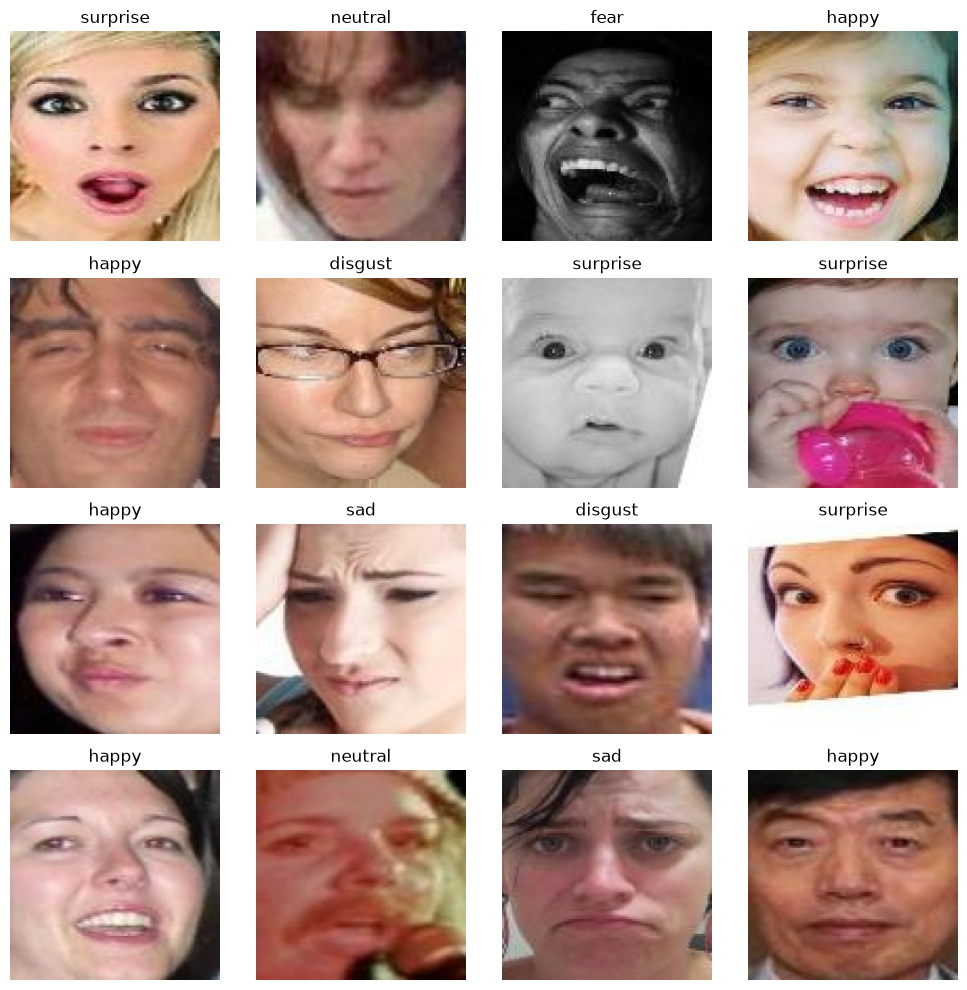

In [26]:
sample = df_train_crop.sample(min(16, len(df_train_crop)), random_state=SEED)

plt.figure(figsize=(10, 10))

for idx, row in enumerate(sample.itertuples(index=False)):
    image = Image.open(row.filepath).convert("RGB")
    ax = plt.subplot(4, 4, idx + 1)
    plt.imshow(image)
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 10. Dataset e DataLoader

In [27]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.92, 1.08),
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class FacialEmotionDataset(Dataset):
    def __init__(self, df, class_to_index, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_index = class_to_index
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_index[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = FacialEmotionDataset(
    df_train_crop,
    class_to_index,
    train_transform,
)

val_dataset = FacialEmotionDataset(
    df_val_crop,
    class_to_index,
    eval_transform,
)

test_dataset = FacialEmotionDataset(
    df_test_crop,
    class_to_index,
    eval_transform,
)

loader_common = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": AMP_ENABLED,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_common,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_common,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_common,
)

print("Batches treino:", len(train_loader))
print("Batches validação:", len(val_loader))
print("Batches teste:", len(test_loader))
print("num_workers:", NUM_WORKERS)


Batches treino: 384
Batches val: 48
Batches teste: 48


## 11. Modelo ConvNeXtTiny

In [28]:
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
model = convnext_tiny(weights=weights)

in_features = model.classifier[2].in_features

model.classifier[2] = nn.Sequential(
    nn.Dropout(p=0.40),
    nn.Linear(in_features, 512),
    nn.GELU(),
    nn.Dropout(p=0.30),
    nn.Linear(512, num_classes),
)

model = model.to(DEVICE)

train_label_indices = (
    df_train_crop["label"]
    .map(class_to_index)
    .to_numpy()
)

raw_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_label_indices,
)

moderate_class_weights = np.clip(
    raw_class_weights,
    0.75,
    2.50,
)

class_weights_tensor = torch.tensor(
    moderate_class_weights,
    dtype=torch.float32,
    device=DEVICE,
)

print("Pesos de classe moderados:")
for class_name, weight in zip(class_names, moderate_class_weights):
    print(f"- {class_name}: {weight:.3f}")

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING,
)

def configurar_estagio_treino(model, stage):
    for parameter in model.features.parameters():
        parameter.requires_grad = False

    for parameter in model.classifier.parameters():
        parameter.requires_grad = True

    if stage == 1:
        print("Estágio 1: somente classificador.")

        optimizer = optim.AdamW(
            model.classifier.parameters(),
            lr=LR_HEAD,
            weight_decay=WEIGHT_DECAY,
        )

    elif stage == 2:
        print("Estágio 2: classificador + últimos blocos.")

        for parameter in model.features[-2:].parameters():
            parameter.requires_grad = True

        optimizer = optim.AdamW(
            [
                {
                    "params": model.features[-2:].parameters(),
                    "lr": LR_LAST_BLOCKS,
                },
                {
                    "params": model.classifier.parameters(),
                    "lr": LR_LAST_BLOCKS * 5,
                },
            ],
            weight_decay=WEIGHT_DECAY,
        )

    else:
        print("Estágio 3: backbone completo com LR baixo.")

        for parameter in model.features.parameters():
            parameter.requires_grad = True

        optimizer = optim.AdamW(
            [
                {
                    "params": model.features.parameters(),
                    "lr": LR_FULL_BACKBONE,
                },
                {
                    "params": model.classifier.parameters(),
                    "lr": LR_FULL_BACKBONE * 5,
                },
            ],
            weight_decay=WEIGHT_DECAY,
        )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.35,
        patience=2,
        min_lr=1e-7,
    )

    return optimizer, scheduler

optimizer, scheduler = configurar_estagio_treino(model, stage=1)
scaler = GradScaler("cuda", enabled=AMP_ENABLED)

print(model.classifier)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 120MB/s]


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=768, out_features=512, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=512, out_features=7, bias=True)
  )
)


/tmp/ipykernel_7211/3908560601.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


## 12. Funções de treino

In [29]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(loader, desc="Treino", leave=False):
        images = images.to(DEVICE, non_blocking=AMP_ENABLED)
        labels = labels.to(DEVICE, non_blocking=AMP_ENABLED)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=DEVICE.type,
            enabled=AMP_ENABLED,
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        scaler.step(optimizer)
        scaler.update()

        predictions = outputs.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, desc="Validação"):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(DEVICE, non_blocking=AMP_ENABLED)
        labels = labels.to(DEVICE, non_blocking=AMP_ENABLED)

        with autocast(
            device_type=DEVICE.type,
            enabled=AMP_ENABLED,
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_predictions.extend(predictions.cpu().numpy().tolist())
        all_probabilities.extend(probabilities.cpu().numpy().tolist())

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "macro_f1": macro_f1,
        "labels": np.array(all_labels),
        "preds": np.array(all_predictions),
        "probs": np.array(all_probabilities),
    }


def salvar_melhor_checkpoint(
    path,
    model,
    epoch,
    stage,
    val_accuracy,
    val_macro_f1,
):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "class_to_index": class_to_index,
            "epoch": epoch,
            "stage": stage,
            "val_accuracy": val_accuracy,
            "val_macro_f1": val_macro_f1,
            "img_size": IMG_SIZE,
            "model_name": MODEL_NAME,
            "class_weights": moderate_class_weights.tolist(),
        },
        path,
    )


def salvar_checkpoint_retomada(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    stage,
    history,
    best_epoch,
    best_val_accuracy,
    best_val_macro_f1,
    epochs_without_improvement,
):
    torch.save(
        {
            "epoch": epoch,
            "stage": stage,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
            "best_epoch": best_epoch,
            "best_val_accuracy": best_val_accuracy,
            "best_val_macro_f1": best_val_macro_f1,
            "epochs_without_improvement": epochs_without_improvement,
            "class_names": class_names,
            "class_to_index": class_to_index,
            "img_size": IMG_SIZE,
            "model_name": MODEL_NAME,
        },
        path,
    )


## 13. Treinamento

In [30]:
best_val_accuracy = 0.0
best_val_macro_f1 = 0.0
best_epoch = 0
epochs_without_improvement = 0
history = []

start_epoch = 1
current_stage = 1

if CHECKPOINT_RESUME_PATH.exists():
    print("Checkpoint de retomada encontrado no Drive.")

    resume_checkpoint = torch.load(
        CHECKPOINT_RESUME_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(
        resume_checkpoint["model_state_dict"]
    )

    current_stage = int(resume_checkpoint["stage"])
    optimizer, scheduler = configurar_estagio_treino(
        model,
        stage=current_stage,
    )

    optimizer.load_state_dict(
        resume_checkpoint["optimizer_state_dict"]
    )
    scheduler.load_state_dict(
        resume_checkpoint["scheduler_state_dict"]
    )
    scaler.load_state_dict(
        resume_checkpoint["scaler_state_dict"]
    )

    history = resume_checkpoint.get("history", [])
    best_epoch = int(resume_checkpoint.get("best_epoch", 0))
    best_val_accuracy = float(
        resume_checkpoint.get("best_val_accuracy", 0.0)
    )
    best_val_macro_f1 = float(
        resume_checkpoint.get("best_val_macro_f1", 0.0)
    )
    epochs_without_improvement = int(
        resume_checkpoint.get(
            "epochs_without_improvement",
            0,
        )
    )

    start_epoch = int(resume_checkpoint["epoch"]) + 1

    print(f"Retomando da época {start_epoch}.")
    print(f"Estágio atual: {current_stage}")
    print(f"Melhor F1 macro: {best_val_macro_f1:.4f}")
else:
    print("Novo treinamento iniciado.")

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\nÉpoca {epoch}/{NUM_EPOCHS}")

    expected_stage = (
        1
        if epoch <= HEAD_ONLY_END_EPOCH
        else 2
        if epoch <= LAST_BLOCKS_END_EPOCH
        else 3
    )

    if expected_stage != current_stage:
        current_stage = expected_stage

        optimizer, scheduler = configurar_estagio_treino(
            model,
            stage=current_stage,
        )

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        desc="Validação",
    )

    scheduler.step(val_metrics["macro_f1"])

    row = {
        "epoch": epoch,
        "stage": current_stage,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "lr_backbone": optimizer.param_groups[0]["lr"],
        "lr_classifier": optimizer.param_groups[-1]["lr"],
    }

    history.append(row)

    pd.DataFrame(history).to_csv(
        HISTORY_PATH,
        index=False,
    )

    print(
        f"stage={current_stage} | "
        f"train_acc={row['train_accuracy']:.4f} | "
        f"val_acc={row['val_accuracy']:.4f} | "
        f"val_macro_f1={row['val_macro_f1']:.4f} | "
        f"train_loss={row['train_loss']:.4f} | "
        f"val_loss={row['val_loss']:.4f} | "
        f"lr={row['lr_backbone']:.2e}"
    )

    improved = (
        val_metrics["macro_f1"]
        > best_val_macro_f1 + 1e-4
    )

    if improved:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_val_accuracy = val_metrics["accuracy"]
        best_epoch = epoch
        epochs_without_improvement = 0

        salvar_melhor_checkpoint(
            CHECKPOINT_BEST_PATH,
            model,
            epoch,
            current_stage,
            best_val_accuracy,
            best_val_macro_f1,
        )

        print(
            "Novo melhor modelo salvo no Drive: "
            f"macro_f1={best_val_macro_f1:.4f} | "
            f"accuracy={best_val_accuracy:.4f}"
        )
    else:
        epochs_without_improvement += 1

        print(
            "Sem melhora no F1 macro por "
            f"{epochs_without_improvement} época(s)."
        )

    salvar_checkpoint_retomada(
        CHECKPOINT_RESUME_PATH,
        model,
        optimizer,
        scheduler,
        scaler,
        epoch,
        current_stage,
        history,
        best_epoch,
        best_val_accuracy,
        best_val_macro_f1,
        epochs_without_improvement,
    )

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping acionado.")
        break

print("\nMelhor época:", best_epoch)
print("Melhor validação accuracy:", best_val_accuracy)
print("Melhor validação macro F1:", best_val_macro_f1)
print("Melhor checkpoint:", CHECKPOINT_BEST_PATH)
print("Checkpoint de retomada:", CHECKPOINT_RESUME_PATH)



Época 1/35


Treino:   0%|          | 0/384 [00:00<?, ?it/s]

/tmp/ipykernel_7211/2645869589.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Validação:   0%|          | 0/48 [00:00<?, ?it/s]

/tmp/ipykernel_7211/2645869589.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791e188ce8e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791e188ce8e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

train_acc=0.9901 | val_acc=0.8565 | train_loss=0.3123 | val_loss=0.6578 | lr=2.45e-06
Sem melhora por 7 época(s).

Época 31/35


Treino:   0%|          | 0/384 [00:00<?, ?it/s]

Validação:   0%|          | 0/48 [00:00<?, ?it/s]

train_acc=0.9898 | val_acc=0.8552 | train_loss=0.3144 | val_loss=0.6602 | lr=2.45e-06
Sem melhora por 8 época(s).
Early stopping acionado.

Melhor época: 23
Melhor validação: 0.857795172863666


## 14. Curvas

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,lr
26,27,0.328123,0.984027,0.670461,0.852577,0.000007
27,28,0.322357,0.987939,0.671178,0.850620,0.000007
28,29,0.317767,0.988917,0.659821,0.852577,0.000002
29,30,0.312312,0.990139,0.657786,0.856491,0.000002
30,31,0.314390,0.989813,0.660185,0.855186,0.000002


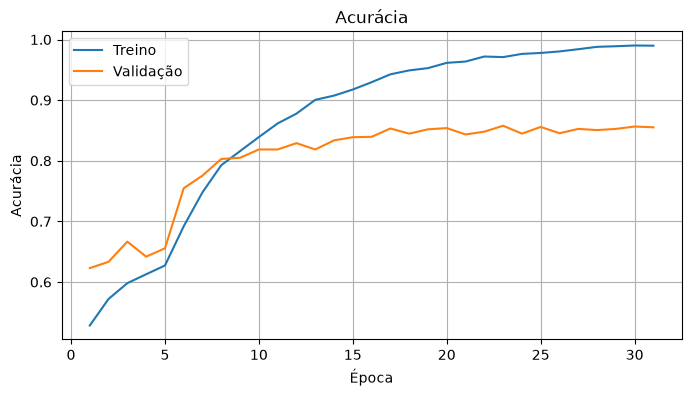

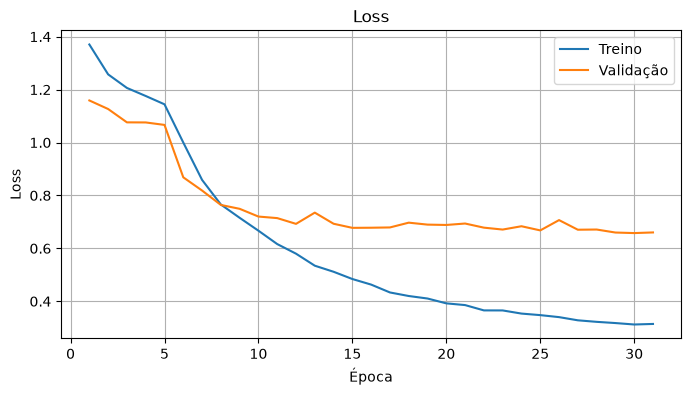

In [31]:
history_df = pd.DataFrame(history)
display(history_df.tail())

history_df.to_csv(
    HISTORY_PATH,
    index=False,
)

accuracy_plot_path = OUTPUT_DIR / "training_accuracy.png"
macro_f1_plot_path = OUTPUT_DIR / "training_macro_f1.png"
loss_plot_path = OUTPUT_DIR / "training_loss.png"

plt.figure(figsize=(8, 4))
plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Treino",
)
plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validação",
)
plt.title("Acurácia")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    accuracy_plot_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    label="F1 macro de validação",
)
plt.title("F1 macro de validação")
plt.xlabel("Época")
plt.ylabel("F1 macro")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    macro_f1_plot_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Treino",
)
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validação",
)
plt.title("Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    loss_plot_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## 15. Avaliação no teste

In [32]:
checkpoint = torch.load(
    CHECKPOINT_BEST_PATH,
    map_location=DEVICE,
    weights_only=False,
)

model = convnext_tiny(weights=None)

in_features = model.classifier[2].in_features

model.classifier[2] = nn.Sequential(
    nn.Dropout(p=0.40),
    nn.Linear(in_features, 512),
    nn.GELU(),
    nn.Dropout(p=0.30),
    nn.Linear(512, num_classes),
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

test_metrics = evaluate(
    model,
    test_loader,
    criterion,
    desc="Teste",
)

test_accuracy = test_metrics["accuracy"]
test_macro_f1 = test_metrics["macro_f1"]
test_loss = test_metrics["loss"]

y_true = test_metrics["labels"]
y_pred = test_metrics["preds"]

print("Test loss     :", test_loss)
print("Test accuracy :", test_accuracy)
print("Test macro F1 :", test_macro_f1)

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

print(report_text)


Teste:   0%|          | 0/48 [00:00<?, ?it/s]

/tmp/ipykernel_7211/2645869589.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Test loss    : 0.6657715971772756
Test accuracy: 0.8514657980456026
              precision    recall  f1-score   support

       angry       0.84      0.73      0.78        81
     disgust       0.63      0.42      0.51        80
        fear       0.55      0.49      0.51        37
       happy       0.92      0.96      0.94       593
     neutral       0.80      0.84      0.82       340
         sad       0.84      0.84      0.84       239
    surprise       0.85      0.85      0.85       165

    accuracy                           0.85      1535
   macro avg       0.78      0.73      0.75      1535
weighted avg       0.85      0.85      0.85      1535



## 16. Matriz de confusão

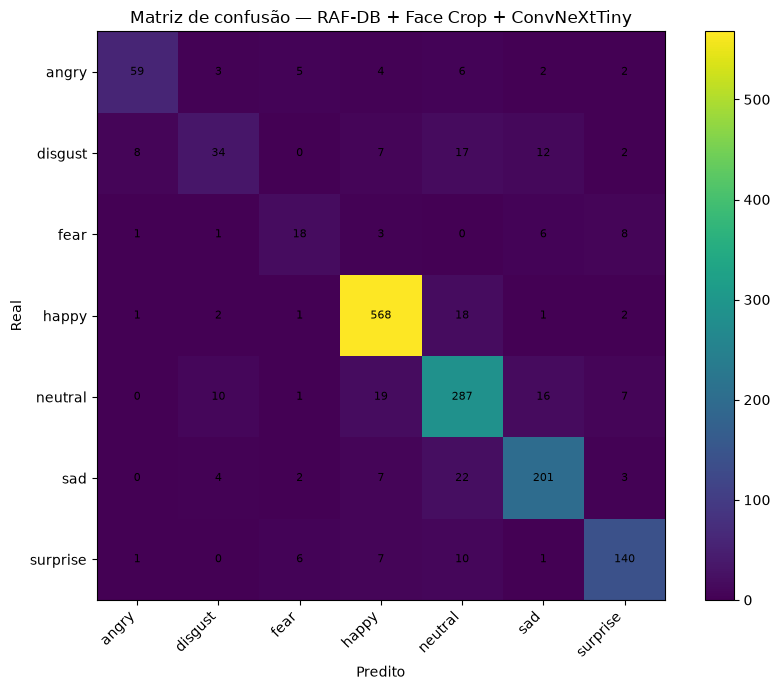

Matriz salva em: /content/emodia_cv_v4_outputs/confusion_matrix_rafdb_convnexttiny_facecrop.png


In [33]:
matriz = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(matriz)
plt.title("Matriz de confusão — RAF-DB + Face Crop + ConvNeXtTiny")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.xticks(np.arange(num_classes), class_names, rotation=45, ha="right")
plt.yticks(np.arange(num_classes), class_names)
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, matriz[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()

confusion_path = OUTPUT_DIR / "confusion_matrix_rafdb_convnexttiny_facecrop.png"
plt.savefig(confusion_path, dpi=160, bbox_inches="tight")
plt.show()

print("Matriz salva em:", confusion_path)


## 17. Labels e métricas

In [36]:
def normalizar_nome_classe(nome):
    return (
        nome.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

emodia_map = {}

for classe in class_names:
    classe_norm = normalizar_nome_classe(classe)

    if "happy" in classe_norm or "happiness" in classe_norm:
        emodia_map[classe] = "ALEGRIA"
    elif "sad" in classe_norm or "sadness" in classe_norm:
        emodia_map[classe] = "TRISTEZA"
    elif "angry" in classe_norm or "anger" in classe_norm:
        emodia_map[classe] = "RAIVA"
    elif "fear" in classe_norm:
        emodia_map[classe] = "MEDO"
    elif "disgust" in classe_norm:
        emodia_map[classe] = "NOJO"
    elif "neutral" in classe_norm:
        emodia_map[classe] = "NEUTRAL"
    elif "surprise" in classe_norm:
        emodia_map[classe] = "SURPRISE"
    elif "contempt" in classe_norm:
        emodia_map[classe] = "CONTEMPT"
    else:
        emodia_map[classe] = "UNKNOWN"

labels = {
    "class_names": class_names,
    "class_to_index": class_to_index,
    "facial_emotion_to_emodia": emodia_map,
    "image_size": IMG_SIZE,
    "model": MODEL_NAME,
    "notes": [
        "Expressão facial aparente, não diagnóstico clínico.",
        "Usar somente como sinal complementar no Emodia.",
        "Emoção principal deve continuar vindo da análise textual/transcrição.",
    ],
}

labels_path = OUTPUT_DIR / "labels.json"

with open(
    labels_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        labels,
        file,
        ensure_ascii=False,
        indent=2,
    )

metrics = {
    "dataset": "RAF-DB",
    "dataset_kaggle": DATASET_KAGGLE,
    "model": MODEL_NAME,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "best_epoch": int(best_epoch),
    "best_val_accuracy": float(best_val_accuracy),
    "best_val_macro_f1": float(best_val_macro_f1),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "classification_report": report_dict,
    "classes": class_names,
    "class_weights": {
        class_name: float(weight)
        for class_name, weight in zip(
            class_names,
            moderate_class_weights,
        )
    },
    "training_stages": {
        "stage_1": f"epochs 1-{HEAD_ONLY_END_EPOCH}: classifier only",
        "stage_2": (
            f"epochs {HEAD_ONLY_END_EPOCH + 1}-"
            f"{LAST_BLOCKS_END_EPOCH}: last blocks"
        ),
        "stage_3": (
            f"epochs {LAST_BLOCKS_END_EPOCH + 1}+"
            ": full backbone"
        ),
    },
    "ethical_note": (
        "Modelo de expressão facial aparente. "
        "Não usar como diagnóstico clínico."
    ),
}

metrics_path = OUTPUT_DIR / "metrics.json"

with open(
    metrics_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metrics,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Labels:", labels_path)
print("Metrics:", metrics_path)


Labels: /content/emodia_cv_v4_outputs/labels.json
Metrics: /content/emodia_cv_v4_outputs/metrics.json


## 18. Exportar ONNX

In [37]:
!pip -q install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 17.3 MB/s eta 0:00:00


In [38]:
onnx_path = OUTPUT_DIR / f"{MODEL_NAME}.onnx"

model.eval()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["image"],
    output_names=["emotion_logits"],
    dynamic_axes={
        "image": {0: "batch_size"},
        "emotion_logits": {0: "batch_size"},
    },
)

print("ONNX salvo em:", onnx_path)


/tmp/ipykernel_7211/2446001417.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0612 21:47:57.875000 7211 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...


[torch.onnx] Optimize the ONNX graph... ✅
ONNX salvo em: /content/emodia_cv_v4_outputs/convnexttiny_rafdb_facecrop.onnx


## 19. Teste visual

In [ ]:
def denormalizar_tensor(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()

model.eval()

images, labels_batch = next(iter(test_loader))
images_device = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images_device)
    probs = torch.softmax(outputs, dim=1)
    preds = probs.argmax(dim=1).cpu()

plt.figure(figsize=(12, 12))

for i in range(min(16, images.size(0))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(denormalizar_tensor(images[i]))

    real = class_names[int(labels_batch[i])]
    pred = class_names[int(preds[i])]
    conf = float(probs[i, preds[i]].cpu())

    plt.title(f"real: {real}\npred: {pred} ({conf:.2f})", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 20. Compactar arquivos finais

In [ ]:
zip_path = Path("/content/emodia_cv_v5_outputs.zip")

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(
    base_name=str(zip_path).replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("ZIP gerado em:", zip_path)
print("Arquivos persistidos no Drive:")

for file in sorted(OUTPUT_DIR.iterdir()):
    print("-", file.name)


## 21. Download no Colab

In [ ]:
from google.colab import files

files.download("/content/emodia_cv_v5_outputs.zip")


## 22. Onde colocar no repositório

Os resultados também ficam persistidos em:

```txt
Google Drive/MyDrive/Emodia/modelos/cv/convnexttiny_rafdb_v5/
```

Depois de baixar o ZIP:

```bash
mkdir -p ml/notebooks/cv ml/models/cv ml/reports/cv

# Notebook:
ml/notebooks/cv/treino_emocao_facial_rafdb_convnexttiny_facecrop_v5_colab.ipynb

# Modelos:
ml/models/cv/convnexttiny_rafdb_facecrop_v5_best.pt
ml/models/cv/convnexttiny_rafdb_facecrop_v5.onnx
ml/models/cv/labels.json

# Relatórios:
ml/reports/cv/metrics.json
ml/reports/cv/history.csv
ml/reports/cv/training_accuracy.png
ml/reports/cv/training_macro_f1.png
ml/reports/cv/training_loss.png
ml/reports/cv/confusion_matrix_rafdb_convnexttiny_facecrop.png
```

O arquivo `*_resume.pt` pode ficar fora do Git por ser apenas um checkpoint de retomada.

Commit sugerido:

```bash
git add ml
git commit -m "feat: add improved ConvNeXtTiny facial emotion model"
```
